<a href="https://colab.research.google.com/github/rishabhg46-bot/machine_learning/blob/main/FEATURE_SCALLING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rishabhg46","key":"3b882595eca8ba2b5f3ea8e1a1438c34"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d rakeshrau/social-network-ads

Dataset URL: https://www.kaggle.com/datasets/rakeshrau/social-network-ads
License(s): unknown
100% 3.27k/3.27k [00:00<00:00, 6.89MB/s]



In [4]:
!unzip social-network-ads.zip

Archive:  social-network-ads.zip
  inflating: Social_Network_Ads.csv  


In [5]:
import pandas as pd

# Read the CSV file directly into a DataFrame
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
83,15711218,Male,35,88000,0
254,15724161,Female,50,44000,0
345,15716781,Female,41,63000,0
246,15638003,Female,35,50000,0
71,15726358,Female,24,27000,0


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased',axis=1), df['Purchased'],test_size=0.2, random_state=0)
X_train.shape, X_test.shape


((320, 4), (80, 4))

# **TRAIN  TEST SPLIT**

In [11]:
from sklearn.preprocessing import StandardScaler

# Drop 'User ID' as it is not a feature and apply one-hot encoding to 'Gender'
X_train_processed = pd.get_dummies(X_train.drop('User ID', axis=1), columns=['Gender'], drop_first=True)
X_test_processed = pd.get_dummies(X_test.drop('User ID', axis=1), columns=['Gender'], drop_first=True)

sc = StandardScaler()

# Fit the scaler on the processed training data and transform both train and test sets
X_train_scaled = sc.fit_transform(X_train_processed)
X_test_scaled = sc.transform(X_test_processed)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Scaler mean for each feature:", sc.mean_)

X_train_scaled shape: (320, 3)
X_test_scaled shape: (80, 3)
Scaler mean for each feature: [3.8218750e+01 6.9928125e+04 4.8750000e-01]


In [13]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train_processed.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test_processed.columns)
X_train_scaled

,Age,EstimatedSalary,Gender_Male
0,1.922950,2.146016,1.025320
1,2.020161,0.378719,-0.975305
2,-1.382215,-0.432499,-0.975305
3,-1.187794,-1.011940,-0.975305
4,1.922950,-0.925024,-0.975305
...,...,...,...
315,0.950843,-1.156800,-0.975305
316,-0.896162,-0.780164,1.025320
317,-0.215686,-0.519415,1.025320
318,-1.090583,-0.461471,-0.975305


In [16]:
np.round(X_train_scaled.describe(), 2)

,Age,EstimatedSalary,Gender_Male
count,320.00,320.00,320.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.97,-1.59,-0.98
25%,-0.80,-0.78,-0.98
50%,-0.02,-0.01,-0.98
75%,0.76,0.52,1.03
max,2.12,2.32,1.03


# *EFFECT OF SCALING*

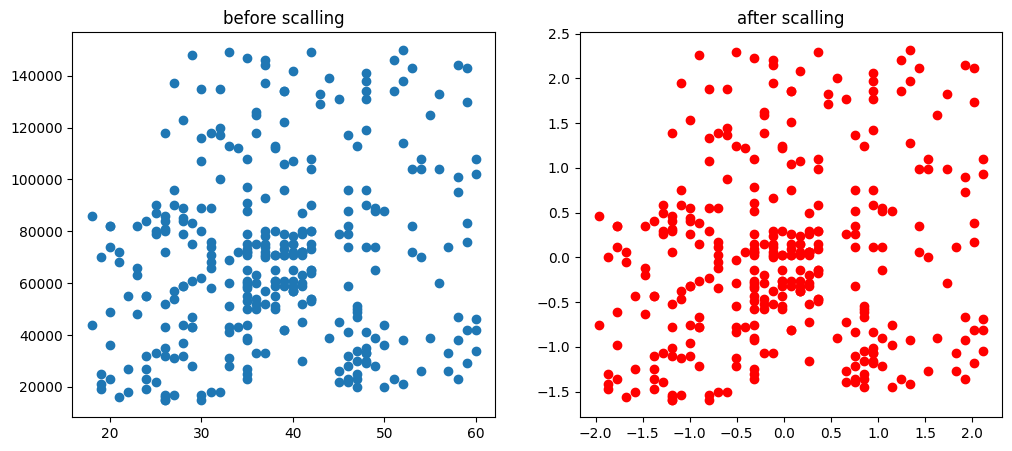

In [19]:
fig, (ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('before scalling')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('after scalling')
plt.show()

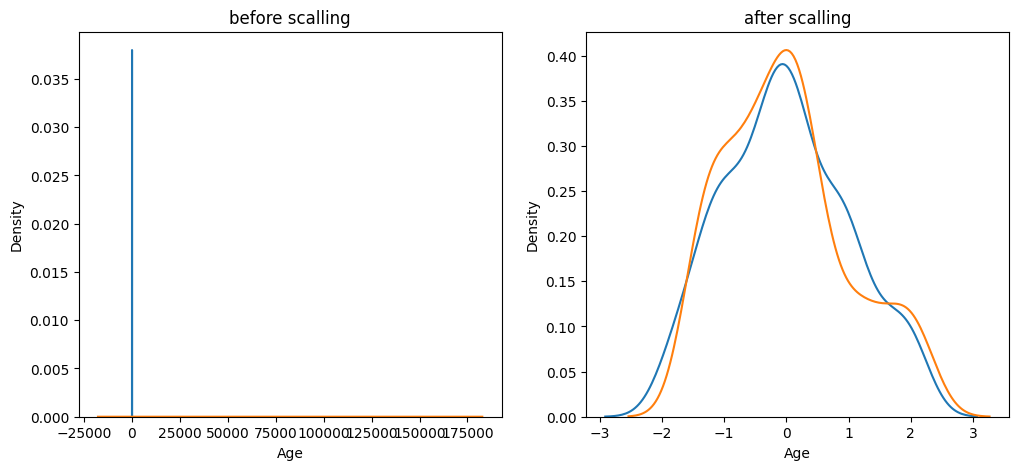

In [20]:
fig, (ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
#before scaling
ax1.set_title('before scalling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
#after scalling
ax2.set_title('after scalling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()


# WHY SACLLING IS IMPORTANT

In [23]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()
lr.fit(X_train_processed,y_train) # Changed X_train to X_train_processed
lr_scaled.fit(X_train_scaled,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [24]:
y_pred=lr.predict(X_test_processed)
y_pred_scaled=lr_scaled.predict(X_test_scaled)
from sklearn.metrics import accuracy_score
print('before scalling',accuracy_score(y_test,y_pred))
print('after scalling',accuracy_score(y_test,y_pred_scaled))

before scalling 0.925
after scalling 0.9125


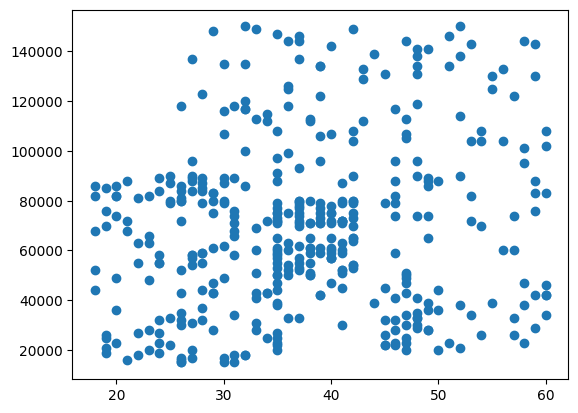

In [26]:
plt.scatter(df['Age'],df['EstimatedSalary'])

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported if not already

# --- 1. Perform Train-Test Split ---
# This divides your dataset into training and testing sets.
# X will contain features (Age, EstimatedSalary, Gender) and y will be the target (Purchased).
# We drop 'Purchased' from df to get features (X) and select 'Purchased' for the target (y).
# random_state ensures reproducibility of the split.
X = df.drop('Purchased', axis=1)
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Shapes after train-test split:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# --- 2. Preprocessing for Scaling (before StandardScaler) ---
# Drop 'User ID' as it is an identifier and not a feature.
# Apply one-hot encoding to the 'Gender' column, converting categorical data to numerical.
# drop_first=True avoids multicollinearity.
X_train_processed = pd.get_dummies(X_train.drop('User ID', axis=1), columns=['Gender'], drop_first=True)
X_test_processed = pd.get_dummies(X_test.drop('User ID', axis=1), columns=['Gender'], drop_first=True)

print("\nShapes after preprocessing (dropping User ID, one-hot encoding Gender):")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

# --- 3. Apply StandardScaler ---
# Initialize the StandardScaler.
sc = StandardScaler()

# Fit the scaler ONLY on the training data to learn parameters (mean, std dev).
# Then transform both training and testing sets using these learned parameters.
X_train_scaled = sc.fit_transform(X_train_processed)
X_test_scaled = sc.transform(X_test_processed)

# Convert scaled arrays back to DataFrames for easier inspection, using the column names.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns)

print("\nShapes after StandardScaler:")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("Scaler mean for each feature (from training data):", sc.mean_)

print("\nFirst 5 rows of X_train_scaled:")
print(X_train_scaled.head())

Shapes after train-test split:
X_train shape: (320, 4)
X_test shape: (80, 4)

Shapes after preprocessing (dropping User ID, one-hot encoding Gender):
X_train_processed shape: (320, 3)
X_test_processed shape: (80, 3)

Shapes after StandardScaler:
X_train_scaled shape: (320, 3)
X_test_scaled shape: (80, 3)
Scaler mean for each feature (from training data): [3.8218750e+01 6.9928125e+04 4.8750000e-01]

First 5 rows of X_train_scaled:
        Age  EstimatedSalary  Gender_Male
0  1.922950         2.146016     1.025320
1  2.020161         0.378719    -0.975305
2 -1.382215        -0.432499    -0.975305
3 -1.187794        -1.011940    -0.975305
4  1.922950        -0.925024    -0.975305


IT SHOWS THERE IS NO EFFECT OF STANDARDIZATION IN OUTLIERS
